In [1]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 60.93 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [ ]:
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

In [2]:
%cd stylegan2-ada-pytorch

/content/stylegan2-ada-pytorch


In [3]:
!mv ../eu.jpeg .


--2025-10-17 23:05:23--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 13.35.37.105, 13.35.37.106, 13.35.37.115, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|13.35.37.105|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘ffhq.pkl’

ffhq.pkl            100%[===================>] 363.94M  21.2MB/s    in 19s     

2025-10-17 23:05:42 (19.7 MB/s) - ‘ffhq.pkl’ saved [381624121/381624121]



In [4]:
!curl -L https://i.imgur.com/JynpBOr.jpeg -o eu.jpeg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2152k  100 2152k    0     0  1221k      0  0:00:01  0:00:01 --:--:-- 1220k


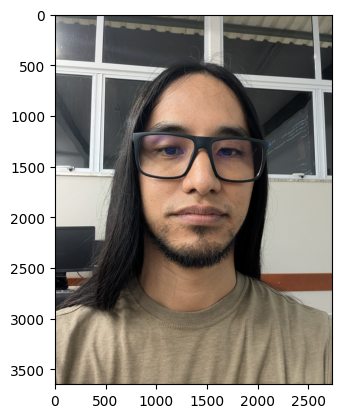

In [5]:
from PIL import Image
eu = Image.open('eu.jpeg')

from matplotlib import pyplot as plt
plt.imshow(eu)

In [6]:
!ls

calc_metrics.py  docker_run.sh	generate.py  projector.py     training
dataset_tool.py  docs		legacy.py    README.md	      train.py
dnnlib		 eu.jpeg	LICENSE.txt  style_mixing.py
Dockerfile	 ffhq.pkl	metrics      torch_utils


In [7]:
%pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.6 MB/s eta 0:00:00


In [8]:
# Projetar uma foto local para ajustar o W que gera uma foto parecida

!python projector.py --network=ffhq.pkl --target=eu.jpeg --outdir=out

Loading networks from "ffhq.pkl"...
Computing W midpoint and stddev using 10000 samples...
Setting up PyTorch plugin "bias_act_plugin"... W1017 23:05:58.851000 6821 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1017 23:05:58.851000 6821 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... W1017 23:06:54.860000 6821 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1017 23:06:54.860000 6821 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
Done.
/content/stylegan2-ada-pytorch/projector.py:120: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.det

In [267]:
import numpy as np

w = np.load("out/projected_w.npz")['w']
print(w.shape)  # usually (1, num_layers, 512)

(1, 18, 512)


In [268]:

import torch
from legacy import load_network_pkl

device = 'cuda'  # or 'cpu'

# Load network
with open("ffhq.pkl", "rb") as f:
    G = load_network_pkl(f)['G_ema'].to(device)  # type: torch.nn.Module

w_plus = torch.from_numpy(w).to(device)

# Generate image
img = G.synthesis(w_plus, noise_mode='const')  # or 'none' if using projector noise
img = (img.clamp(-1, 1) + 1) * 127.5
img = img.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')


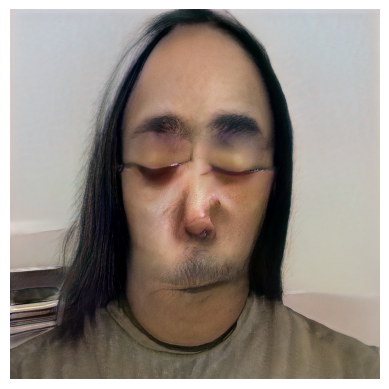

In [269]:
import matplotlib.pyplot as plt

plt.imshow(img[0])
plt.axis('off') # Hide axes
plt.show()

In [270]:

import torch
from legacy import load_network_pkl

device = 'cuda'  # or 'cpu'


w_plus2 = torch.from_numpy(w).to(device)
# w_plus2[:,:,:10] = 0
# w_plus2[:,:,20:50] = 0
w_plus2[:,:,0:256] = 0


# Generate image
img = G.synthesis(w_plus2, noise_mode='const')  # or 'none' if using projector noise
img = (img.clamp(-1, 1) + 1) * 127.5
img = img.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')


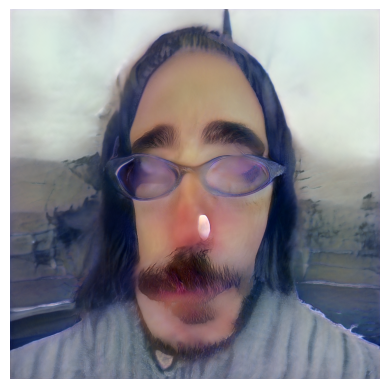

In [271]:
import matplotlib.pyplot as plt

plt.imshow(img[0])
plt.axis('off') # Hide axes
plt.show()

In [378]:
!gdown 1cUv_reLE6k3604or78EranS7XzuVMWeO

Downloading...
From (original): https://drive.google.com/uc?id=1cUv_reLE6k3604or78EranS7XzuVMWeO
From (redirected): https://drive.google.com/uc?id=1cUv_reLE6k3604or78EranS7XzuVMWeO&confirm=t&uuid=b08fb99d-7a3d-4928-ae38-436d2016e92e
To: /content/stylegan2-ada-pytorch/e4e_ffhq_encode.pt
100% 1.20G/1.20G [00:20<00:00, 57.3MB/s]


In [379]:
!git clone https://github.com/omertov/encoder4editing.git

Cloning into 'encoder4editing'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 172 (delta 49), reused 42 (delta 42), pack-reused 94 (from 1)
Receiving objects: 100% (172/172), 33.43 MiB | 9.90 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [386]:
%cd /content/stylegan2-ada-pytorch
%cd encoder4editing
!mkdir -p img
!mv ../eu.jpeg img

/content/stylegan2-ada-pytorch
/content/stylegan2-ada-pytorch/encoder4editing


In [392]:
!mv ../e4e_ffhq_encode.pt .

In [398]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

[Errno 2] No such file or directory: '/content/encoder4editing/pretrained_models'
/content/stylegan2-ada-pytorch/encoder4editing
--2025-10-18 00:09:04--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-10-18 00:09:04--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  12.7MB/s    in 5.5s    

2025-10-18 00:09:11 (11.1 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [399]:
!mkdir pretrained_models
!mv shape_predictor_68_face_landmarks.dat pretrained_models/

In [401]:
if not hasattr(Image, 'ANTIALIAS'):
    Image.ANTIALIAS = Image.Resampling.LANCZOS

In [403]:
!pip install pillow==9.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 56.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pillow: filename=Pillow-9.5.0-cp312-cp312-linux_x86_64.whl size=1210275 sha256=f23db5f7dd843de8cf6b8f9cd5133b5e13fa32bc2534ac15d3b3f3037d33d470
  Stored in directory: /root/.cache/pip/wheels/ea/de/2e/75a6399e5d8cd3a55c13c8f0658d996d4ce4cff37389de044c
Successfully built pillow
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


In [405]:
!mkdir out

In [406]:
!PYTHONPATH=. python scripts/inference.py \
  --images_dir=img \
  --align \
  --save_dir out \
  e4e_ffhq_encode.pt

W1018 00:13:36.822000 24852 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1018 00:13:36.822000 24852 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
W1018 00:13:36.865000 24852 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1018 00:13:36.865000 24852 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
Loading e4e over the pSp framework from checkpoint: e4e_ffhq_encode.pt
images path: img
dataset length: 1
Aligned image has shape: (256, 256)
Saving inversion images


In [572]:
%cd ..

/content/stylegan2-ada-pytorch


In [573]:

import torch
from legacy import load_network_pkl

device = 'cuda'  # or 'cpu'


# Sample random latent z
z = torch.randn(1, G.z_dim, device=device)

# Eu
w1 = torch.from_numpy(w).to(device)
# Map to W
w2 = G.mapping(z, None)  # w has shape [1, num_ws, 512]

# Generate image
img = G.synthesis(w2, noise_mode='const')  # or 'none' if using projector noise
img = (img.clamp(-1, 1) + 1) * 127.5
img = img.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')



In [575]:
w_plus = torch.load('encoder4editing/out/latents.pt').to(device)


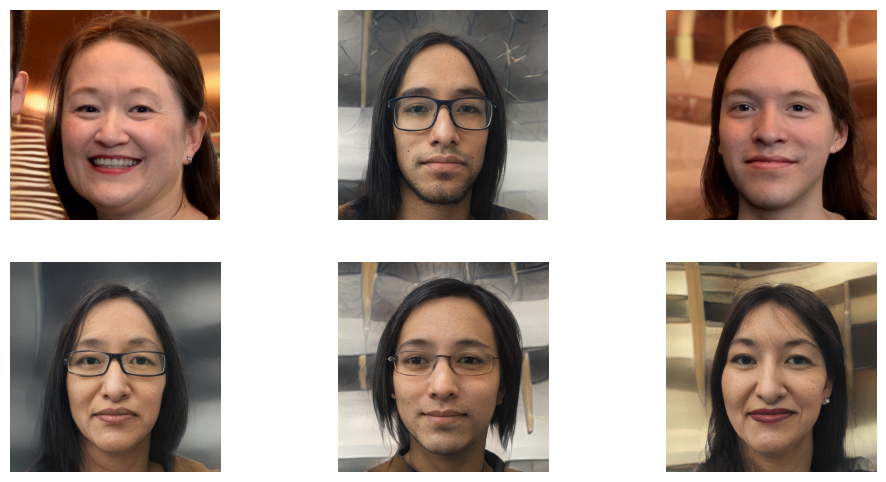

In [577]:
import matplotlib.pyplot as plt


# Outra pessoa
z = torch.randn(1, G.z_dim, device=device)
w2 = G.mapping(z, None)  # w has shape [1, num_ws, 512]
# Generate image
img = G.synthesis(w2, noise_mode='const')  # or 'none' if using projector noise
img = (img.clamp(-1, 1) + 1) * 127.5
img = img.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')

w_plus2 = w2.detach().clone()
w3 = w_plus.detach().clone()
w_plus2[:,0:2,:] = w3[:,0:2,:]
w_plus2[:,4:8,:] = w3[:,4:8,:]

# Generate image
img2 = G.synthesis(w_plus, noise_mode='const')  # or 'none' if using projector noise
img2 = (img2.clamp(-1, 1) + 1) * 127.5
img2 = img2.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')


# Generate image
img3 = G.synthesis(w_plus2, noise_mode='const')  # or 'none' if using projector noise
img3 = (img3.clamp(-1, 1) + 1) * 127.5
img3 = img3.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')

fig, axes = plt.subplots(2, 3, figsize=(12, 6)) # 2 row, 3 columns


axes[0,0].imshow(img[0])
axes[0,0].axis('off') # Hide axes


axes[0,1].imshow(img2[0])
axes[0,1].axis('off') # Hide axes

axes[0,2].imshow(img3[0])
axes[0,2].axis('off') # Hide axes


w_plus2 = w_plus.detach().clone()
w_plus2[:,0:1,:] = w2[:,0:1,:]
w_plus2[:,6:7,:] = w2[:,6:7,:]

img4 = G.synthesis(w_plus2, noise_mode='const')  # or 'none' if using projector noise
img4 = (img4.clamp(-1, 1) + 1) * 127.5
img4 = img4.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')

axes[1,0].imshow(img4[0])
axes[1,0].axis('off') # Hide axes

# Interleave
w_plus2 = w_plus.detach().clone()
w_plus2[:,1,:] = w2[:,1,:]
w_plus2[:,3,:] = w3[:,3,:]
w_plus2[:,5,:] = w2[:,5,:]
w_plus2[:,7,:] = w3[:,7,:]
w_plus2[:,9,:] = w2[:,9,:]
w_plus2[:,11,:] = w3[:,11,:]
w_plus2[:,13,:] = w3[:,13,:]
w_plus2[:,15,:] = w3[:,15,:]

img5 = G.synthesis(w_plus2, noise_mode='const')  # or 'none' if using projector noise
img5 = (img5.clamp(-1, 1) + 1) * 127.5
img5 = img5.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')

axes[1,1].imshow(img5[0])
axes[1,1].axis('off') # Hide axes

# Interleave opposite
w_plus2 = w_plus.detach().clone()
w_plus2[:,0,:] = w2[:,0,:]
w_plus2[:,2,:] = w2[:,2,:]
w_plus2[:,6,:] = w2[:,6,:]
w_plus2[:,8,:] = w3[:,8,:]
w_plus2[:,10,:] = w2[:,10,:]
w_plus2[:,12,:] = w3[:,12,:]
w_plus2[:,14,:] = w3[:,14,:]
w_plus2[:,16,:] = w3[:,16,:]


img6 = G.synthesis(w_plus2, noise_mode='const')  # or 'none' if using projector noise
img6 = (img6.clamp(-1, 1) + 1) * 127.5
img6 = img6.permute(0, 2, 3, 1).cpu().numpy().astype('uint8')
axes[1,2].imshow(img6[0])
axes[1,2].axis('off') # Hide axes



plt.show()

